# Notebook 07 — Benchmarking de precios de mercado

Este notebook formaliza los **parámetros de mercado español** que alimentan el modelo Monte Carlo del Notebook 06, dejando cada cifra trazada a su fuente, URL y fecha de acceso. Es la pieza que conecta la simulación económica con el contexto real del sector privado de salud en España.

**Enfoque de obtención de datos.** Las fuentes oficiales (INE, Ministerio de Sanidad) no publican precios del sector privado a nivel de servicio, por lo que los parámetros se construyen por **triangulación**: precios publicados de clínicas privadas, tarifas de pasarelas de SMS y evidencia experimental sobre el efecto de los recordatorios. La recogida de precios es **documental** —se consultan directamente las tarifas públicas de cada proveedor, citando su URL—, lo que mantiene el notebook reproducible aunque las webs cambien con el tiempo. Se prioriza varias fuentes por parámetro para acotar un **rango** (min/moda/max de una distribución triangular) en lugar de fijar un único valor puntual, que sería frágil.

**Por qué el efecto viene de la literatura y no del dato propio.** El Notebook 04 mostró que el efecto causal del SMS no es identificable de forma estable en estos datos observacionales (la positividad se rompe y la contingencia ATO no es robusta a la especificación). Por eso el parámetro de efecto del Monte Carlo se ancla en evidencia experimental publicada —una reducción *relativa* del no-show— y no en la estimación propia. Este notebook documenta esos anclajes junto al resto de parámetros económicos.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / 'src'))
sys.path.append(str(Path.cwd() / 'src'))

import pandas as pd
import mercado
import rutas

mercado.configurar_estilo()
pd.set_option('display.max_colwidth', 60)
RUTA_NB06_META = rutas.REPORTES / 'nb06_metadatos_v1.json'

## 1. Parámetros del Monte Carlo y su trazabilidad

Cada fila es un parámetro del modelo del Notebook 06. La columna `tipo` distingue las cifras **verificadas** en fuente (efecto, tasa basal, valor de consulta, coste del SMS) de los **supuestos declarados** sin fuente citable (volumen mensual y margen de contribución), que se exploran mediante rangos de sensibilidad. Esta separación es deliberada: el lector puede ver de un vistazo qué descansa en evidencia y qué en hipótesis razonadas.

In [2]:
params = mercado.tabla_parametros()
params[['parametro', 'distribucion', 'min', 'moda', 'max', 'unidad', 'tipo']]

,parametro,distribucion,min,moda,max,unidad,tipo
0,reduccion_relativa_noshow,triangular,0.180,0.250,0.335,proporción,verificado
1,tasa_basal_noshow,triangular,0.100,0.125,0.200,proporción,verificado
2,valor_consulta,triangular,60.000,100.000,160.000,€,verificado
3,coste_sms,triangular,0.034,0.045,0.096,€,verificado
4,volumen_mensual,uniforme,200.000,NaN,800.000,citas/mes,supuesto
5,margen_contribucion,triangular,0.600,0.750,0.900,proporción,supuesto


In [3]:
# Fuente de cada parámetro
params[['parametro', 'fuente', 'fecha_acceso']]

,parametro,fuente,fecha_acceso
0,reduccion_relativa_noshow,"Robotham 2016 (RR no-show 0,75 [0,68–0,82]); Gurol-Urgan...",2026-06-14
1,tasa_basal_noshow,"Hernández-García 2018 (12,5%, referencia contextual); ra...",2026-06-14
2,valor_consulta,IMDA (160 €); Clínica Buenavista (60/100 €),2026-06-14
3,coste_sms,"Esendex (0,034–0,096 €); LabsMobile (0,045 €)",2026-06-14
4,volumen_mensual,Supuesto declarado (sensibilidad sobre el tamaño de la c...,2026-06-14
5,margen_contribucion,Supuesto declarado (estructura de coste de servicios san...,2026-06-14


## 2. Evidencia de precios publicados

Los rangos del valor de consulta (60/100/160 €) y del coste del SMS (0,034/0,045/0,096 €) no se inventan: se apoyan en precios publicados de clínicas privadas españolas y de dos pasarelas de SMS. Se listan aquí las observaciones puntuales con su proveedor y URL.

In [4]:
evidencia = mercado.tabla_evidencia_precios()
evidencia[['categoria', 'proveedor', 'servicio', 'precio_eur', 'url']]

,categoria,proveedor,servicio,precio_eur,url
0,consulta,Clínica Buenavista (Madrid),Fisioterapia (valoración),60.000,https://clinicabuenavista.com/servicios/precios/
1,consulta,Clínica Buenavista (Madrid),Ginecología,100.000,https://clinicabuenavista.com/servicios/precios/
2,consulta,Clínica Buenavista (Madrid),Urología,100.000,https://clinicabuenavista.com/servicios/precios/
3,consulta,IMDA,Dermatología (primera consulta),160.000,https://www.imda.es/tarifas/
4,sms,Esendex,Pack prepago 50.000 SMS,0.034,https://www.esendex.es/precios/
5,sms,LabsMobile,25.000 SMS a España,0.045,https://www.labsmobile.com/es/blog/cuanto-puede-costar-u...
6,sms,Esendex,Pack prepago 500 SMS,0.096,https://www.esendex.es/precios/


El siguiente gráfico sitúa los precios de consulta observados frente al rango triangular usado en la simulación: la moda (100 €) coincide con las consultas intermedias y los extremos (60 € y 160 €) acotan el abanico de especialidades.

In [5]:
ruta_fig = rutas.FIGURAS / 'nb07_precios_consulta_v1.png'
mercado.plot_precios_consulta(evidencia, params, ruta_fig)
print('Figura guardada en', ruta_fig)

Figura guardada en /Users/sergi/Library/CloudStorage/OneDrive-Personal/Documentos/TFG Analytics Scripts/Kaggle Processor/outputs/figuras/nb07_precios_consulta_v1.png


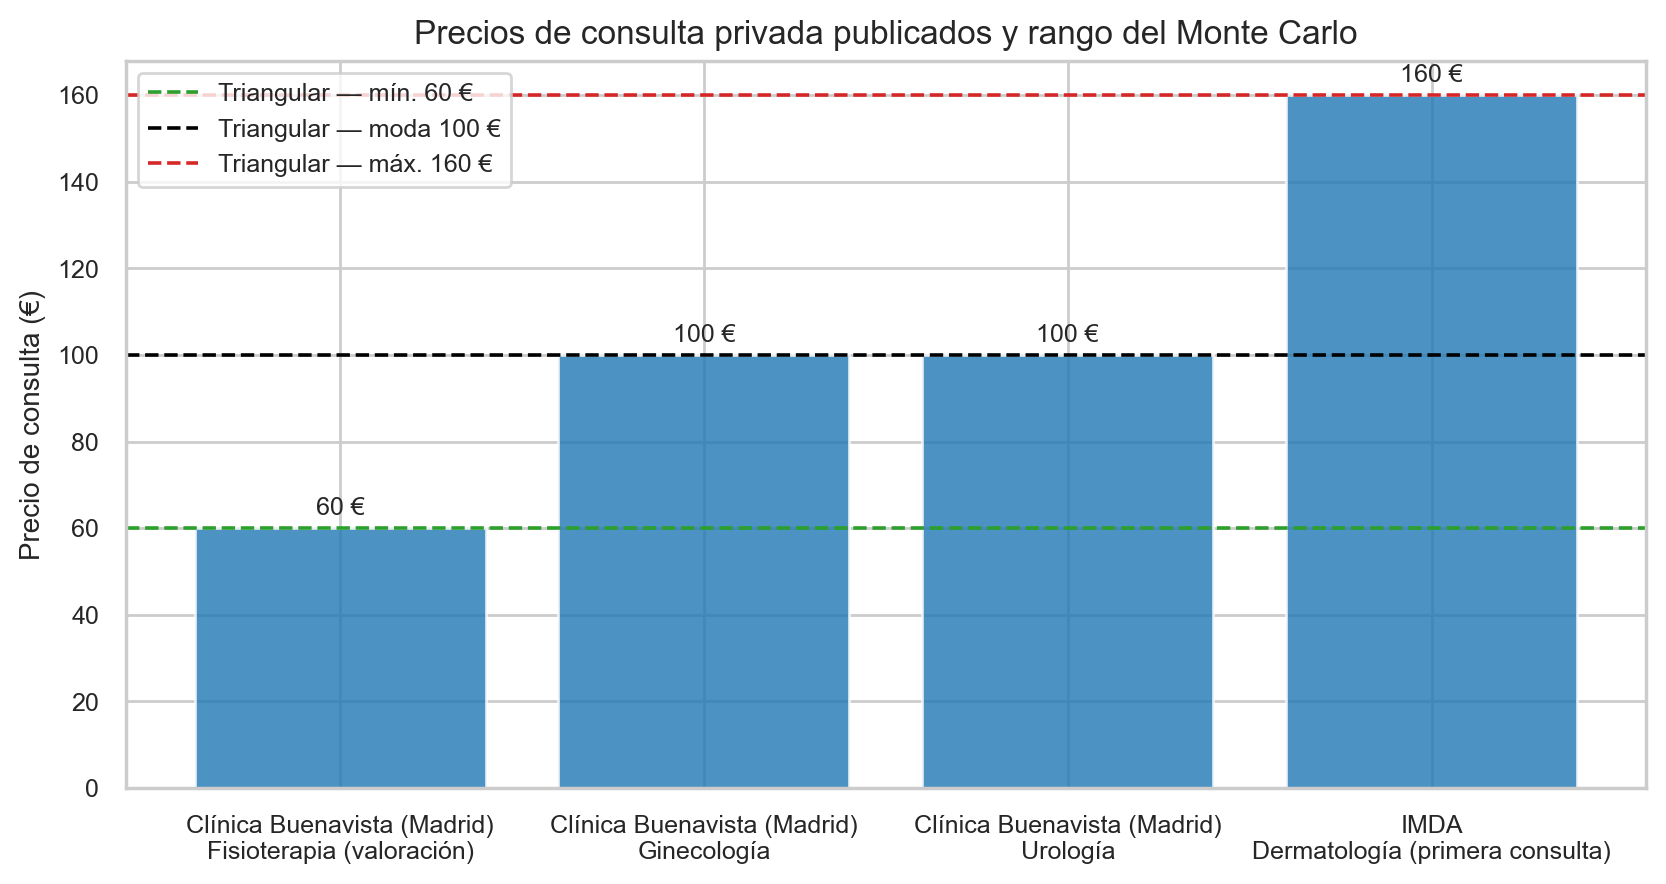

In [6]:
from IPython.display import Image
Image(filename=str(ruta_fig))

## 3. Anclajes del efecto del recordatorio

El parámetro de efecto del Monte Carlo es una **reducción relativa del no-show** modelada como triangular(0,18 / 0,25 / 0,335). Sus vértices proceden de meta-análisis y revisiones sistemáticas: Robotham (2016) aporta la moda (−25 %) y el mínimo (límite superior del intervalo, RR 0,82 → 18 %), y la revisión Cochrane (Gurol-Urganci 2013, pub3) aporta el máximo a partir de la reducción entre brazos (32,2 % → 21,4 %). Guy (2012) se usa solo como comprobación de coherencia. Hernández-García (2018) fija la referencia contextual de la tasa basal española.

In [7]:
fuentes = mercado.tabla_fuentes_efecto()
fuentes[['fuente', 'metrica', 'rol']]

,fuente,metrica,rol
0,"Robotham et al. (2016), BMJ Open","RR no-show 0,75 [0,68–0,82]; −25% de inasistencia","Ancla MODA (0,25) y MIN (0,18); meta-análisis más recien..."
1,"Gurol-Urganci et al. (2013), Cochrane CD007458.pub3","Asistencia 67,8%→78,6%; no-show 32,2%→21,4%; RR asistenc...","Ancla MAX (0,335); reducción relativa entre brazos"
2,"Guy et al. (2012), Health Services Research","OR asistencia 1,48 [1,23–1,72] (8 ECA)",Comprobación de coherencia; no es ancla de la triangular
3,"Hernández-García et al. (2018), J Healthc Qual Res","Absentismo 12,5% (consulta externa, Zaragoza)","Referencia contextual de la tasa basal española (moda 0,..."


## 4. Reconciliación con el Notebook 06

Para garantizar que esta tabla documental y la simulación no se desincronicen, se contrastan automáticamente los rangos aquí documentados con los que el Notebook 06 dejó persistidos en su sidecar. La comprobación falla si algún min/moda/max no coincide.

In [8]:
reconciliacion = mercado.reconciliar_con_nb06(params, RUTA_NB06_META)
print('Todos los parámetros coinciden con el NB06:',
      bool(reconciliacion['coincide'].all()))
reconciliacion

Todos los parámetros coinciden con el NB06: True


,parametro,estadistico,documentado,usado_nb06,coincide
0,reduccion_relativa_noshow,min,0.180,0.180,True
1,reduccion_relativa_noshow,moda,0.250,0.250,True
2,reduccion_relativa_noshow,max,0.335,0.335,True
3,tasa_basal_noshow,min,0.100,0.100,True
4,tasa_basal_noshow,moda,0.125,0.125,True
5,tasa_basal_noshow,max,0.200,0.200,True
6,valor_consulta,min,60.000,60.000,True
7,valor_consulta,moda,100.000,100.000,True
8,valor_consulta,max,160.000,160.000,True
9,coste_sms,min,0.034,0.034,True


## 5. Contexto sectorial y persistencia

Como referencia cualitativa del tamaño del problema, la prensa económica estima que las ausencias cuestan entre 2.500 y 7.500 €/mes a una clínica privada, con un 12–19 % de citas perdidas (El Independiente, 29/09/2025). Es una cifra sectorial de contexto, no un parámetro del modelo. El valor mensual recuperado que estima el Notebook 06 (mediana ≈ 1.300 €) se interpreta como una **fracción** de ese coste total —la parte recuperable con recordatorios—, no como su totalidad.

Se persisten las dos tablas (parámetros y evidencia) y un sidecar con el resumen, que el documento escrito puede citar directamente.

In [9]:
mercado.persistir_tabla(params, rutas.REPORTES / 'nb07_parametros_mercado_v1.csv')
mercado.persistir_tabla(evidencia, rutas.REPORTES / 'nb07_evidencia_precios_v1.csv')

metadata = {
    'notebook': '07_benchmarking_mercado',
    'fecha_acceso': mercado.FECHA_ACCESO,
    'n_parametros': int(len(params)),
    'n_verificados': int((params['tipo'] == 'verificado').sum()),
    'n_supuestos': int((params['tipo'] == 'supuesto').sum()),
    'n_precios_observados': int(len(evidencia)),
    'reconciliacion_nb06_ok': bool(reconciliacion['coincide'].all()),
    'enfoque': 'Recogida documental de tarifas públicas + triangulación; '
               'sin extracción programática para preservar reproducibilidad.',
}
mercado.persistir_sidecar(metadata, rutas.REPORTES / 'nb07_metadatos_v1.json')
metadata

{'notebook': '07_benchmarking_mercado',
 'fecha_acceso': '2026-06-14',
 'n_parametros': 6,
 'n_verificados': 4,
 'n_supuestos': 2,
 'n_precios_observados': 7,
 'reconciliacion_nb06_ok': True,
 'enfoque': 'Recogida documental de tarifas públicas + triangulación; sin extracción programática para preservar reproducibilidad.'}

## 6. Síntesis

Los parámetros que alimentan la simulación económica quedan documentados y trazados a sus fuentes, separando lo verificado de lo supuesto, y reconciliados con los valores efectivamente usados en el Notebook 06. Con ello, la recomendación de pricing basada en valor descansa sobre parámetros de mercado españoles citables y reproducibles, y sobre un efecto anclado en evidencia experimental —no en la estimación causal propia, que el Notebook 04 mostró no identificable de forma estable. La medición del efecto real en el contexto de aiXtensa queda planteada como una prueba A/B dentro del propio servicio.